In [2]:
import csv
import matplotlib.pyplot as plt
import os
import re
import shutil

shutil.rmtree('./results', ignore_errors=True)

In [3]:
def execute_sample_test(is_chain_test:bool, device:str, loop_step:int, max_val:int, n_trials:int, fixed_val:int, split:bool=False, printing:bool=False):
    """
    if is_chain_test is True, max_val represents the maximum number of chains,
    and fixed_val represents the fixed number of steps per chain.
    If is_chain_test is False, max_val represents the maximum number of steps per chain,
    and fixed_val represents the fixed number of chains.
    """
    if device not in ['cpu', 'cuda']:
        raise ValueError("Device must be 'cpu' or 'cuda'")
    if is_chain_test:
        cmd = f"python sampling_chain_dependance.py --device {device} --n-chains {max_val} --loop-step {loop_step} --n-trials {n_trials} --n-steps {fixed_val}"
    else:
        print("Executing step dependence test")
        cmd = f"python sampling_step_dependance.py --device {device} --n-steps {max_val} --loop-step {loop_step} --n-trials {n_trials} --n-chains {fixed_val}"
    if split:
        cmd += " --split"
    if printing:
        os.system(cmd)
    else:
        os.system(cmd + " > /dev/null 2>&1")

# Testing number of chains dependance

In [4]:
shutil.rmtree('./results', ignore_errors=True)
CHAIN_TEST = True
DEVICES = ['cpu', 'cuda']  # 'cpu' or 'cuda'
LOOP_STEP = 1000
MAX_CHAINS = 5000
N_TRIALS = 5
N_STEPS_PER_CHAIN = 1_000
for DEVICE in DEVICES:
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, MAX_CHAINS, N_TRIALS, N_STEPS_PER_CHAIN, split=False)
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, MAX_CHAINS, N_TRIALS, N_STEPS_PER_CHAIN, split=True)

Reading file: ./results/cuda/times_with_1000_split_False.csv
Reading file: ./results/cuda/times_with_1000_split_True.csv
Reading file: ./results/cpu/times_with_1000_split_False.csv
Reading file: ./results/cpu/times_with_1000_split_True.csv


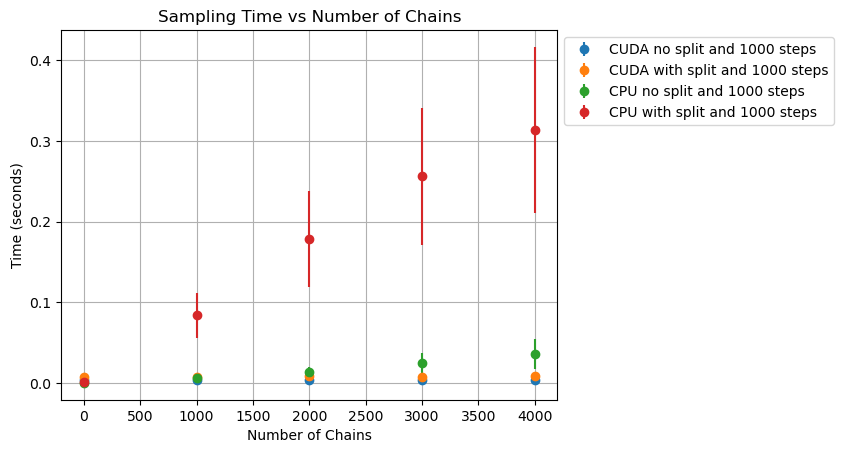

In [5]:
def extract_info_from_filename(filename):
    match = re.search(r"times_with_(\d+)_split_(True|False)", filename)
    if match:
        n_chains = int(match.group(1))
        split = match.group(2) == "True"
        return n_chains, split
    return None

def read_files(device):
    files = os.listdir(f"./results/{device}")
    times_split = {}
    for i,file in enumerate(files):
        times_split[i] = {"data": [], "metadata": {}}
        with open(f"./results/{device}/{file}", mode="r", newline="") as f:
            print(f"Reading file: {f.name}")
            reader = csv.reader(f)
            for row in reader:
                if row[0] != "Number of Chains":  # Skip header
                    times_split[i]["data"].append((int(row[0]), float(row[1]), float(row[2])))
                info = extract_info_from_filename(file)
                if info:
                    n_chains, split = info
                    times_split[i]["metadata"] = {"n_steps": n_chains, "split": split}
    return times_split

times_cuda = read_files("cuda")
times_cpu = read_files("cpu")

def plot_from_times_dict(times_dict, label_prefix):
    for key, value in times_dict.items():
        label = f"{label_prefix} {'with' if value['metadata']['split'] else 'no'} split and {value['metadata']['n_steps']} steps"
        # if not value['metadata']['split'] and value['metadata']['n_steps'] == 1000:
        plt.errorbar(
                [x[0] for x in value['data']],
                [x[1] for x in value['data']],
                yerr=[x[2] for x in value['data']],
                fmt='o',
                label=label
            )

plot_from_times_dict(times_cuda, 'CUDA')
plot_from_times_dict(times_cpu, 'CPU')


plt.xlabel('Number of Chains')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Chains')
plt.legend(
    loc='upper left',           # the corner of the legend box
    bbox_to_anchor=(1, 1),      # position of the legend outside the plot (x=1, y=1)
    borderaxespad=0.5           # optional padding
)
# plt.semilogy()
plt.grid(True)

In [6]:
shutil.rmtree('./results/steps', ignore_errors=True)
CHAIN_TEST = False

STEPS_MAX = 10_000
N_TRIALS = 5
LOOP_STEP = 1000
N_CHAINS = 500
for DEVICE in DEVICES:
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, STEPS_MAX, N_TRIALS, N_CHAINS, split=False)
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, STEPS_MAX, N_TRIALS, N_CHAINS, split=True)

Executing step dependence test
Executing step dependence test
Executing step dependence test
Executing step dependence test


Reading file: ./results/steps/cuda/times_with_500_split_False.csv
Reading file: ./results/steps/cuda/times_with_500_split_True.csv
Reading file: ./results/steps/cpu/times_with_500_split_False.csv
Reading file: ./results/steps/cpu/times_with_500_split_True.csv


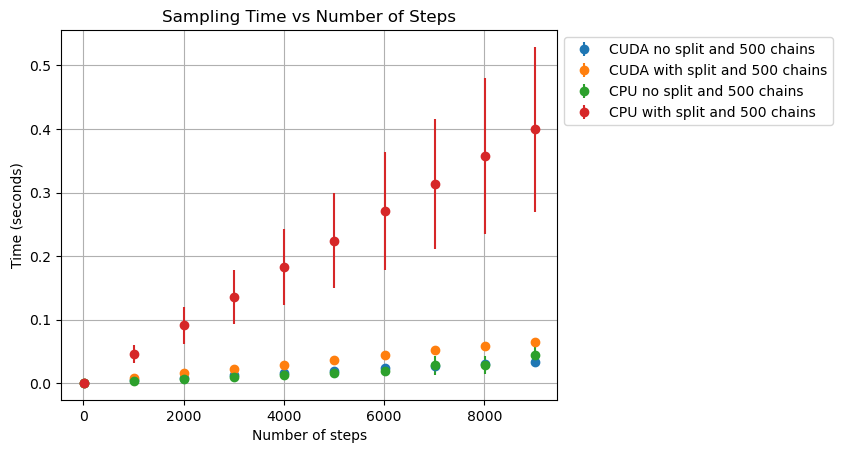

In [7]:
def read_files_steps(device):
    files = os.listdir(f"./results/steps/{device}")
    times_split = {}
    for i,file in enumerate(files):
        times_split[i] = {"data": [], "metadata": {}}
        with open(f"./results/steps/{device}/{file}", mode="r", newline="") as f:
            print(f"Reading file: {f.name}")
            reader = csv.reader(f)
            for row in reader:
                if row[0] != "Number of Steps":  # Skip header
                    times_split[i]["data"].append((int(row[0]), float(row[1]), float(row[2])))
                info = extract_info_from_filename(file)
                if info:
                    n_chains, split = info
                    times_split[i]["metadata"] = {"n_steps": n_chains, "split": split}
    return times_split

times_cuda_steps = read_files_steps("cuda")
times_cpu_steps = read_files_steps("cpu")
def plot_from_times_dict_steps(times_dict, label_prefix):
    for key, value in times_dict.items():
        label = f"{label_prefix} {'with' if value['metadata']['split'] else 'no'} split and {value['metadata']['n_steps']} chains"
        # if not value['metadata']['split'] and value['metadata']['n_steps'] == 1000:
        plt.errorbar(
                [x[0] for x in value['data']],
                [x[1] for x in value['data']],
                yerr=[x[2] for x in value['data']],
                fmt='o',
                label=label
            )

plot_from_times_dict_steps(times_cuda_steps, 'CUDA')
plot_from_times_dict_steps(times_cpu_steps, 'CPU')


plt.xlabel('Number of steps')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Steps')
plt.legend(
    loc='upper left',           # the corner of the legend box
    bbox_to_anchor=(1, 1),      # position of the legend outside the plot (x=1, y=1)
    borderaxespad=0.5           # optional padding
)
# plt.semilogy()
plt.grid(True)